# DATASCI 503, Homework 9: Clustering and Principal Component Analysis

In this assignment, you will practice hierarchical clustering, K-means clustering, and Principal Component Analysis (PCA). You will work with both synthetic dissimilarity matrices and real-world data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

## Part 1: Hierarchical Clustering with a Dissimilarity Matrix

Consider the following dissimilarity matrix for four observations:

$$D = \begin{bmatrix}
0 & 0.3 & 0.4 & 0.7 \\
0.3 & 0 & 0.5 & 0.8 \\
0.4 & 0.5 & 0 & 0.45 \\
0.7 & 0.8 & 0.45 & 0
\end{bmatrix}$$

The rows and columns correspond to observations 1, 2, 3, and 4 respectively.

---

**Problem 1a (ISLP Ch 12, Exercise 2):** Complete Linkage Dendrogram

Using the dissimilarity matrix above, perform hierarchical clustering with **complete linkage** and plot the dendrogram.

Store the linkage result in a variable called `linkage_complete`.

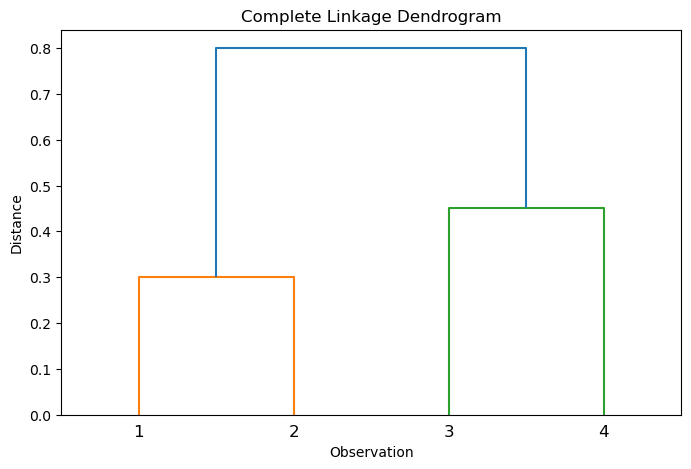

In [2]:
dissimilarity_matrix = np.array(
    [
        [0, 0.3, 0.4, 0.7],
        [0.3, 0, 0.5, 0.8],
        [0.4, 0.5, 0, 0.45],
        [0.7, 0.8, 0.45, 0],
    ]
)
observation_names = np.array(["1", "2", "3", "4"])

# Convert dissimilarity matrix to condensed form and compute complete linkage
condensed_dist = squareform(dissimilarity_matrix)
linkage_complete = linkage(condensed_dist, method='complete')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linkage_complete, labels=observation_names)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

In [3]:
# Test assertions
assert linkage_complete is not None, "linkage_complete should be defined"
assert linkage_complete.shape == (3, 4), "Linkage matrix should have shape (3, 4)"
print("All tests passed!")

All tests passed!


---

**Problem 1b:** Single Linkage Dendrogram

Now perform hierarchical clustering with **single linkage** on the same dissimilarity matrix and plot the dendrogram.

Store the linkage result in a variable called `linkage_single`.

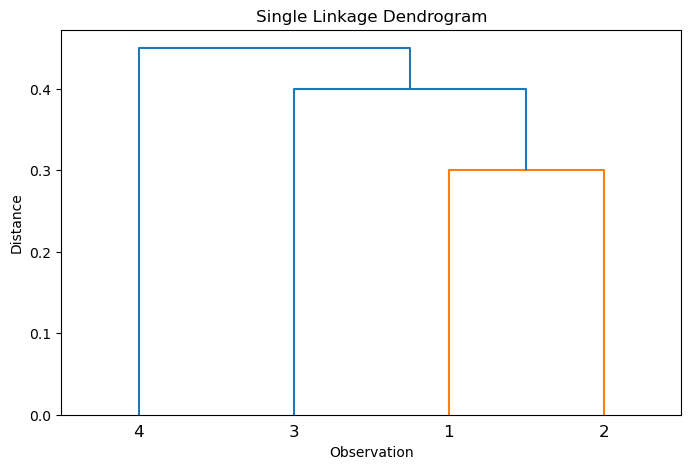

In [4]:
# Single linkage clustering
linkage_single = linkage(condensed_dist, method='single')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linkage_single, labels=observation_names)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

In [5]:
# Test assertions
assert linkage_single is not None, "linkage_single should be defined"
assert linkage_single.shape == (3, 4), "Linkage matrix should have shape (3, 4)"
print("All tests passed!")

All tests passed!


---

**Problem 1c:** Cutting the Complete Linkage Dendrogram

Cut the **complete linkage** dendrogram at a height that produces exactly **2 clusters**. Use a distance threshold of `t=0.5`.

Store the cluster assignments in a variable called `clusters_complete`.

Print the cluster memberships showing which observations belong to each cluster.

In [6]:
# Cut complete linkage dendrogram at t=0.5 to get 2 clusters
clusters_complete = fcluster(linkage_complete, t=0.5, criterion='distance')

# Print cluster memberships
for cluster_id in np.unique(clusters_complete):
    members = observation_names[clusters_complete == cluster_id]
    print(f"Cluster {cluster_id}: Observations {', '.join(members)}")

Cluster 1: Observations 1, 2
Cluster 2: Observations 3, 4


In [7]:
# Test assertions
assert clusters_complete is not None, "clusters_complete should be defined"
assert len(clusters_complete) == 4, "Should have cluster assignments for 4 observations"
assert len(np.unique(clusters_complete)) == 2, "Should produce exactly 2 clusters"
print("All tests passed!")

All tests passed!


---

**Problem 1d:** Cutting the Single Linkage Dendrogram

Cut the **single linkage** dendrogram at a height of `t=0.42` to produce 2 clusters.

Store the cluster assignments in a variable called `clusters_single`.

Print the cluster memberships.

In [8]:
# Cut single linkage dendrogram at t=0.42 to get 2 clusters
clusters_single = fcluster(linkage_single, t=0.42, criterion='distance')

# Print cluster memberships
for cluster_id in np.unique(clusters_single):
    members = observation_names[clusters_single == cluster_id]
    print(f"Cluster {cluster_id}: Observations {', '.join(members)}")

Cluster 1: Observations 1, 2, 3
Cluster 2: Observations 4


In [9]:
# Test assertions
assert clusters_single is not None, "clusters_single should be defined"
assert len(clusters_single) == 4, "Should have cluster assignments for 4 observations"
print("All tests passed!")

All tests passed!


---

**Problem 1e:** Reordering the Dendrogram

Dendrograms can look different depending on how sibling nodes are ordered, even though they represent the same clustering. Demonstrate this by reordering the observations and showing that the dendrogram looks different but represents the same hierarchical structure.

Swap the order of observations: use the order [2, 1, 4, 3] instead of [1, 2, 3, 4].

Store the new linkage result in `linkage_reordered` and plot the dendrogram.

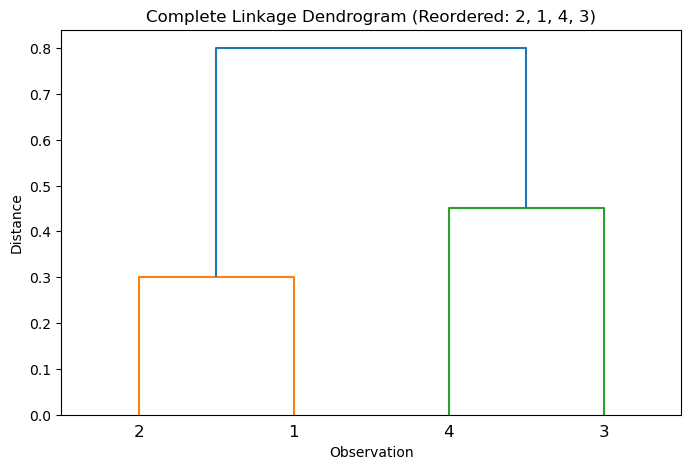

In [10]:
# Reorder observations: use order [2, 1, 4, 3] (0-indexed: [1, 0, 3, 2])
reorder_idx = [1, 0, 3, 2]
dissimilarity_reordered = dissimilarity_matrix[np.ix_(reorder_idx, reorder_idx)]
reordered_names = observation_names[reorder_idx]

# Compute complete linkage on reordered matrix
condensed_reordered = squareform(dissimilarity_reordered)
linkage_reordered = linkage(condensed_reordered, method='complete')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linkage_reordered, labels=reordered_names)
plt.title("Complete Linkage Dendrogram (Reordered: 2, 1, 4, 3)")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

In [11]:
# Test assertions
assert linkage_reordered is not None, "linkage_reordered should be defined"
assert linkage_reordered.shape == (3, 4), "Linkage matrix should have shape (3, 4)"
print("All tests passed!")

All tests passed!


## Part 2: Principal Component Analysis Theory

Consider a dataset with 2 features. The eigenvectors and eigenvalues of the covariance matrix are:

$$U = \begin{bmatrix} u_1 & u_2 \end{bmatrix} = \begin{bmatrix} 0.6 & -0.8 \\ 0.8 & 0.6 \end{bmatrix}$$

$$\Lambda = \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix} = \begin{bmatrix} 4 & 0 \\ 0 & 1 \end{bmatrix}$$

where $u_1$ and $u_2$ are the principal component directions (columns of $U$) and $\lambda_1, \lambda_2$ are the corresponding eigenvalues (variances).

---

**Problem 2a:** Computing the Covariance Matrix (free response)

Given the eigenvectors $U$ and eigenvalues $\Lambda$, compute the original covariance matrix using the relationship:

$$\Sigma = U \Lambda U^T$$

Show your work and express the final answer as a 2x2 matrix.


$U \Lambda U^T = \begin{bmatrix} 0.6 & -0.8 \\ 0.8 & 0.6 \end{bmatrix} \begin{bmatrix} 4 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} 0.6 & -0.8 \\ 0.8 & 0.6 \end{bmatrix}^T$

$U \Lambda U^T = \begin{bmatrix} 0.6 & -0.8 \\ 0.8 & 0.6 \end{bmatrix} \begin{bmatrix} 4 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} 0.6 & 0.8 \\ -0.8 & 0.6 \end{bmatrix}$

$U \Lambda U^T = \begin{bmatrix} 0.6(4)+(-0.8)(0) & 0.6(0)+(-0.8)(1) \\ 0.8(4)+0.6(0) & 0.8(0)+0.6(1) \end{bmatrix} \begin{bmatrix} 0.6 & 0.8 \\ -0.8 & 0.6 \end{bmatrix}$

$U \Lambda U^T = \begin{bmatrix} 2.4 & -0.8 \\ 3.2 & 0.6 \end{bmatrix} \begin{bmatrix} 0.6 & 0.8 \\ -0.8 & 0.6 \end{bmatrix}$

$U \Lambda U^T = \begin{bmatrix} 2.4(0.6)+(-0.8)(-0.8) & 2.4(0.8)+(-0.8)(0.6) \\ 3.2(0.6)+0.6(-0.8) & 3.2(0.8)+0.6(0.6) \end{bmatrix}$

$U \Lambda U^T = \begin{bmatrix} 1.44 + 0.64 & 1.92 - 0.48 \\ 1.92 - 0.48 & 2.56 + 0.36 \end{bmatrix}$ 

$U \Lambda U^T = \begin{bmatrix} 2.08 & 1.44 \\ 1.44 & 2.92 \end{bmatrix}$

---

**Problem 2b:** Variance Explained (free response)

What percentage of the total variance is explained by the first principal component?

Show your calculation.

The total variance is the sum of the eigenvalues:

$$\text{Total Variance} = \lambda_1 + \lambda_2 = 4 + 1 = 5$$

The proportion of variance explained by the first principal component is:

### $\frac{\lambda_1}{\lambda_1 + \lambda_2} = \frac{4}{5} = 0.80 = \mathbf{80\%}$

---

**Problem 2c:** Computing Principal Component Scores (free response)

For a data point $x = [1, 2]$, compute the scores (projections) onto both principal components.

Recall that the score for PC $i$ is computed as $PC_i = x \cdot u_i$.

Show your work.

For the data point $x = [1, 2]$:

**PC1 score:**

$PC_{score \ 1} = x \cdot u_1 = [1, 2] \cdot [0.6, 0.8] = 1(0.6) + 2(0.8) = 0.6 + 1.6 = \mathbf{2.2}$

**PC2 score:**

$PC_{score \ 2} = x \cdot u_2 = [1, 2] \cdot [-0.8, 0.6] = 1(-0.8) + 2(0.6) = -0.8 + 1.2 = \mathbf{0.4}$

## Part 3: Clustering US Arrests Data

In this question, you will apply clustering techniques to the US Arrests dataset, which contains violent crime rates per 100,000 residents for each US state. The variables are:
- **Murder**: Murder arrests per 100,000
- **Assault**: Assault arrests per 100,000
- **UrbanPop**: Percent urban population
- **Rape**: Rape arrests per 100,000

In [12]:
# Load the data
arrests = pd.read_csv("./data/arrests.csv")
state_names = arrests["rownames"].values
features = arrests.drop(["rownames"], axis=1)

print(f"Dataset shape: {features.shape}")
print(f"Features: {list(features.columns)}")
features.head()

FileNotFoundError: [Errno 2] No such file or directory: './data/arrests.csv'

---

**Problem 3a:** Hierarchical Clustering Dendrogram

Perform hierarchical clustering on the (unscaled) US Arrests data using **complete linkage** and plot the dendrogram.

Store the linkage result in a variable called `arrests_linkage`.

In [ ]:
# Hierarchical clustering on unscaled arrests data with complete linkage
arrests_linkage = linkage(features, method='complete', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(arrests_linkage, labels=state_names, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage, Unscaled)")
plt.xlabel("State")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
# Test assertions
assert arrests_linkage is not None, "arrests_linkage should be defined"
assert arrests_linkage.shape[0] == 49, "Linkage should have 49 merges (50 states - 1)"
assert arrests_linkage.shape[1] == 4, "Linkage matrix should have 4 columns"
print("All tests passed!")

---

**Problem 3b:** Cutting into 5 Clusters

Cut the dendrogram at a distance threshold of `t=75` to obtain cluster assignments.

Store the cluster labels in a variable called `hierarchical_labels`.

Print which states belong to each cluster.

In [ ]:
# Cut dendrogram at t=75 to get clusters
hierarchical_labels = fcluster(arrests_linkage, t=75, criterion='distance')

# Print cluster memberships
for cluster_id in np.unique(hierarchical_labels):
    members = state_names[hierarchical_labels == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(members)}")
    print()

In [ ]:
# Test assertions
assert hierarchical_labels is not None, "hierarchical_labels should be defined"
assert len(hierarchical_labels) == 50, "Should have labels for 50 states"
num_clusters = len(np.unique(hierarchical_labels))
assert num_clusters == 5, f"Should produce 5 clusters at t=75, got {num_clusters}"
print("All tests passed!")

Here is a helper function to create silhouette plots for evaluating cluster quality:

In [ ]:
def silhouette_plot(data, labels):
    """Create a silhouette plot and return the average silhouette score."""
    silhouette_avg = silhouette_score(data, labels, metric="euclidean")
    sample_silhouette_values = silhouette_samples(data, labels)
    y_lower = 10

    for cluster_id in np.unique(labels):
        cluster_silhouette_values = sample_silhouette_values[labels == cluster_id]
        cluster_silhouette_values.sort()

        cluster_size = cluster_silhouette_values.shape[0]
        y_upper = y_lower + cluster_size

        color = plt.cm.nipy_spectral(float(cluster_id) / 5)
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        plt.plot(
            cluster_silhouette_values,
            np.arange(y_lower, y_upper),
            "k.",
            alpha=0.7,
        )
        plt.text(-0.05, y_lower + 0.5 * cluster_size, str(cluster_id))
        y_lower = y_upper + 10

    plt.xlabel("Silhouette Coefficient Values")
    plt.ylabel("Cluster Label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    return silhouette_avg


# Create silhouette plot for hierarchical clustering
plt.figure(figsize=(10, 7))
silhouette_hierarchical = silhouette_plot(features, hierarchical_labels)
plt.title(
    f"Silhouette Analysis - Hierarchical Clustering (avg={silhouette_hierarchical:.3f})",
    fontsize=14,
    fontweight="bold",
)
plt.show()

---

**Problem 3c:** K-Means Clustering

Apply K-means clustering to the (unscaled) US Arrests data with `n_clusters=5` and `random_state=33`.

Store the fitted KMeans object in a variable called `kmeans_model` and the cluster labels (1-indexed) in `kmeans_labels`.

Print which states belong to each cluster and compare the silhouette score with hierarchical clustering.

In [ ]:
# K-Means clustering with 5 clusters
kmeans_model = KMeans(n_clusters=5, random_state=33, n_init=10)
kmeans_model.fit(features)

# Labels are 0-indexed, convert to 1-indexed
kmeans_labels = kmeans_model.labels_ + 1

# Print cluster memberships
for cluster_id in np.unique(kmeans_labels):
    members = state_names[kmeans_labels == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(members)}")
    print()

In [ ]:
# Test assertions
assert kmeans_model is not None, "kmeans_model should be defined"
assert kmeans_labels is not None, "kmeans_labels should be defined"
assert len(kmeans_labels) == 50, "Should have labels for 50 states"
assert len(np.unique(kmeans_labels)) == 5, "Should have exactly 5 clusters"
print("All tests passed!")

In [ ]:
# Create silhouette plot for K-means
plt.figure(figsize=(10, 7))
silhouette_kmeans = silhouette_plot(features, kmeans_labels)
plt.title(
    f"Silhouette Analysis - K-Means Clustering (avg={silhouette_kmeans:.3f})",
    fontsize=14,
    fontweight="bold",
)
plt.show()

print("\nSilhouette Score Comparison:")
print(f"  Hierarchical: {silhouette_hierarchical:.4f}")
print(f"  K-Means:      {silhouette_kmeans:.4f}")

---

**Problem 3d:** Effect of Scaling

The features in the arrests dataset have very different scales (e.g., UrbanPop is a percentage while Assault can be in the hundreds). Scaling the features before clustering can significantly affect the results.

Use [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) to scale the features, then repeat the hierarchical clustering (complete linkage, cut at `t=3.2` for 5 clusters) and K-means clustering (`n_clusters=5`, `random_state=33`).

Store the scaled data in `features_scaled`, the hierarchical labels in `hierarchical_labels_scaled`, and the K-means labels in `kmeans_labels_scaled`.

Compare the silhouette scores with and without scaling.

In [ ]:
# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Hierarchical clustering on scaled data (complete linkage, cut at t=3.2)
arrests_linkage_scaled = linkage(features_scaled, method='complete', metric='euclidean')
hierarchical_labels_scaled = fcluster(arrests_linkage_scaled, t=3.2, criterion='distance')

# K-Means on scaled data
kmeans_model_scaled = KMeans(n_clusters=5, random_state=33, n_init=10)
kmeans_model_scaled.fit(features_scaled)
kmeans_labels_scaled = kmeans_model_scaled.labels_ + 1

# Print cluster memberships for hierarchical (scaled)
print("=== Hierarchical Clustering (Scaled) ===")
for cluster_id in np.unique(hierarchical_labels_scaled):
    members = state_names[hierarchical_labels_scaled == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(members)}")
    print()

# Print cluster memberships for K-Means (scaled)
print("=== K-Means Clustering (Scaled) ===")
for cluster_id in np.unique(kmeans_labels_scaled):
    members = state_names[kmeans_labels_scaled == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(members)}")
    print()

In [ ]:
# Test assertions
assert features_scaled is not None, "features_scaled should be defined"
assert hierarchical_labels_scaled is not None, "hierarchical_labels_scaled should be defined"
assert kmeans_labels_scaled is not None, "kmeans_labels_scaled should be defined"
assert features_scaled.shape == features.shape, "Scaled features should have same shape"
print("All tests passed!")

In [ ]:
# Silhouette plots for scaled data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
silhouette_hier_scaled = silhouette_plot(features_scaled, hierarchical_labels_scaled)
axes[0].set_title(
    f"Hierarchical (Scaled) - avg={silhouette_hier_scaled:.3f}",
    fontsize=12,
    fontweight="bold",
)

plt.sca(axes[1])
silhouette_kmeans_scaled = silhouette_plot(features_scaled, kmeans_labels_scaled)
axes[1].set_title(
    f"K-Means (Scaled) - avg={silhouette_kmeans_scaled:.3f}",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("\nSilhouette Score Comparison:")
print(f"  Unscaled Hierarchical: {silhouette_hierarchical:.4f}")
print(f"  Scaled Hierarchical:   {silhouette_hier_scaled:.4f}")
print(f"  Unscaled K-Means:      {silhouette_kmeans:.4f}")
print(f"  Scaled K-Means:        {silhouette_kmeans_scaled:.4f}")

---

**Problem 3e:** PCA on Arrests Data

Apply Principal Component Analysis to the (unscaled) arrests data with 3 components using [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

Store the fitted PCA object in a variable called `pca_model`.

Report:
1. The variance explained by each principal component
2. The proportion of variance explained by each component

In [ ]:
# PCA on unscaled arrests data with 3 components
pca_model = PCA(n_components=3)
pca_model.fit(features)

# Report variance explained
print("Variance explained by each PC:")
for i, var in enumerate(pca_model.explained_variance_):
    print(f"  PC{i+1}: {var:.4f}")

print("\nProportion of variance explained by each PC:")
for i, ratio in enumerate(pca_model.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print(f"\nCumulative variance explained: {pca_model.explained_variance_ratio_.sum()*100:.2f}%")

In [ ]:
# Test assertions
assert pca_model is not None, "pca_model should be defined"
assert hasattr(pca_model, "explained_variance_"), "PCA model should be fitted"
assert len(pca_model.explained_variance_) == 3, "Should have 3 components"
print("All tests passed!")